Unit of analysis: (pathogen, antibiotic_class)
*Features focusing on summary stats

-Overall danger
-Overall AMR burden
-Ranking combinations

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

data_directory = Path.cwd() / "csv_files"
dalys  = pd.read_csv(data_directory / "dalys.CSV")
deaths = pd.read_csv(data_directory / "deaths.CSV")
ylds   = pd.read_csv(data_directory / "ylds.CSV")
ylls   = pd.read_csv(data_directory / "ylls.CSV")

def filtered_df(df):
    return df[
        (df["metric_name"] == "Count") &
        (df["sex_name"] == "All") &
        (df["age_group_name"] == "All Ages") &
        (df["counterfactual"] == "Drug-susceptible infection") &
        (df["infectious_syndrome"] == "All infectious syndromes")
    ].copy()

f_deaths = filtered_df(deaths)
f_dalys  = filtered_df(dalys)
f_ylls   = filtered_df(ylls)
f_ylds   = filtered_df(ylds)

keys = ["location_name", "pathogen", "antibiotic_class"]

f_deaths = f_deaths[keys + ['val']].rename(columns={'val': 'deaths'})
f_dalys  = f_dalys[keys  + ['val']].rename(columns={'val': 'dalys'})
f_ylls   = f_ylls[keys   + ['val']].rename(columns={'val': 'ylls'})
f_ylds   = f_ylds[keys   + ['val']].rename(columns={'val': 'ylds'})

merged = (f_deaths
          .merge(f_dalys, on=keys, how='inner')
          .merge(f_ylls,  on=keys, how='inner')
          .merge(f_ylds,  on=keys, how='inner'))

merged_clean = merged[
    ~merged['pathogen'].str.contains('All', case=False) &
    ~merged['antibiotic_class'].str.contains('one or more', case=False)
].copy()

print("Merged shape:", merged_clean.shape)

feature_matrix = (
    merged_clean
    .groupby(['pathogen', 'antibiotic_class'])
    .agg(
        total_deaths = ('deaths', 'sum'),
        total_ylds=('ylds', 'sum'),
    )
    .reset_index()
)

key_features = ['total_deaths', 'total_ylds']

feature_matrix[['total_deaths', 'total_ylds']] =( feature_matrix[['total_deaths', 'total_ylds']].clip(lower=0))

print("\nFeature matrix shape:", feature_matrix.shape)
print(feature_matrix.sort_values('total_deaths', ascending=False).head(5).to_string(index=False))

Merged shape: (3096, 7)

Feature matrix shape: (86, 4)
               pathogen                antibiotic_class  total_deaths  total_ylds
  Staphylococcus aureus                     Methicillin  46830.357949 4985.283317
       Escherichia coli                Fluoroquinolones  12833.137158 3865.011048
       Escherichia coli Third-generation cephalosporins  12545.404699 4146.879447
Acinetobacter baumannii                     Carbapenems  12324.422269  972.646257
 Pseudomonas aeruginosa                     Carbapenems  11685.306684 1578.409348


In [64]:
fm3  = pd.read_csv('amr_feature_matrix.csv')
X3   = np.load('amr_X_scaled.npy')

key_features_3 = ['log_burden', 'mortality_prop', 'resistance_attr_frac']

print(f"Feature matrix shape: {fm3.shape}")

Feature matrix shape: (86, 10)


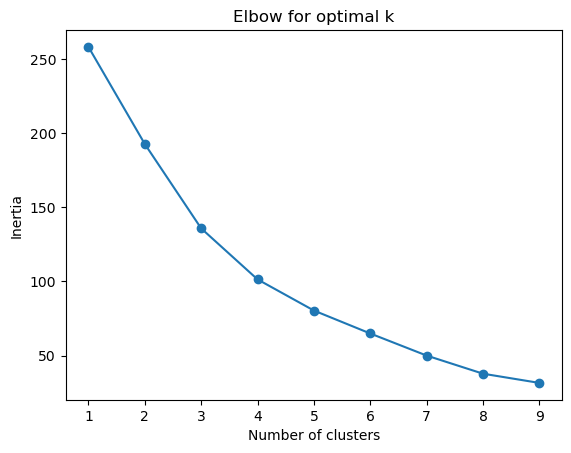

WCSS at k =1: 258.00000000000006
WCSS at k =2: 192.56845507512216
Decrease from previous k = 65.4315449248779
WCSS at k =3: 135.7072649922076
Decrease from previous k = 56.86119008291456
WCSS at k =4: 101.32853780127199
Decrease from previous k = 34.37872719093561
WCSS at k =5: 80.33930153366684
Decrease from previous k = 20.98923626760515
WCSS at k =6: 64.8732065531414
Decrease from previous k = 15.46609498052544
WCSS at k =7: 49.99271478990235
Decrease from previous k = 14.88049176323905
WCSS at k =8: 37.77695946135988
Decrease from previous k = 12.215755328542471
WCSS at k =9: 31.559691133021897
Decrease from previous k = 6.217268328337983


In [65]:
# elbow

# elbow method to find optimal k clusters

inertias_3 = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters = k, random_state=42, n_init = 10)
    labels = kmeans.fit_predict(X3)
    inertias_3.append(kmeans.inertia_)

plt.plot(range(1,10), inertias_3, marker='o')
plt.title('Elbow for optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


for i in range(len(inertias)):
        print(f"WCSS at k ={i+1}: {inertias_3[i]}")
        if i >0:
            decrease = inertias_3[i-1] - inertias_3[i]
            [i]
            print(f"Decrease from previous k = {decrease}")

Cluster sizes:
cluster_label
High burden        55
Low burden         28
Moderate burden     3
Name: count, dtype: int64

Cluster mean profiles:
                 log_burden  mortality_prop  resistance_attr_frac
cluster_label                                                    
Low burden           3.6863          0.9893                0.2210
Moderate burden      3.7897          0.8898                0.1500
High burden          4.7687          0.9932                0.0914


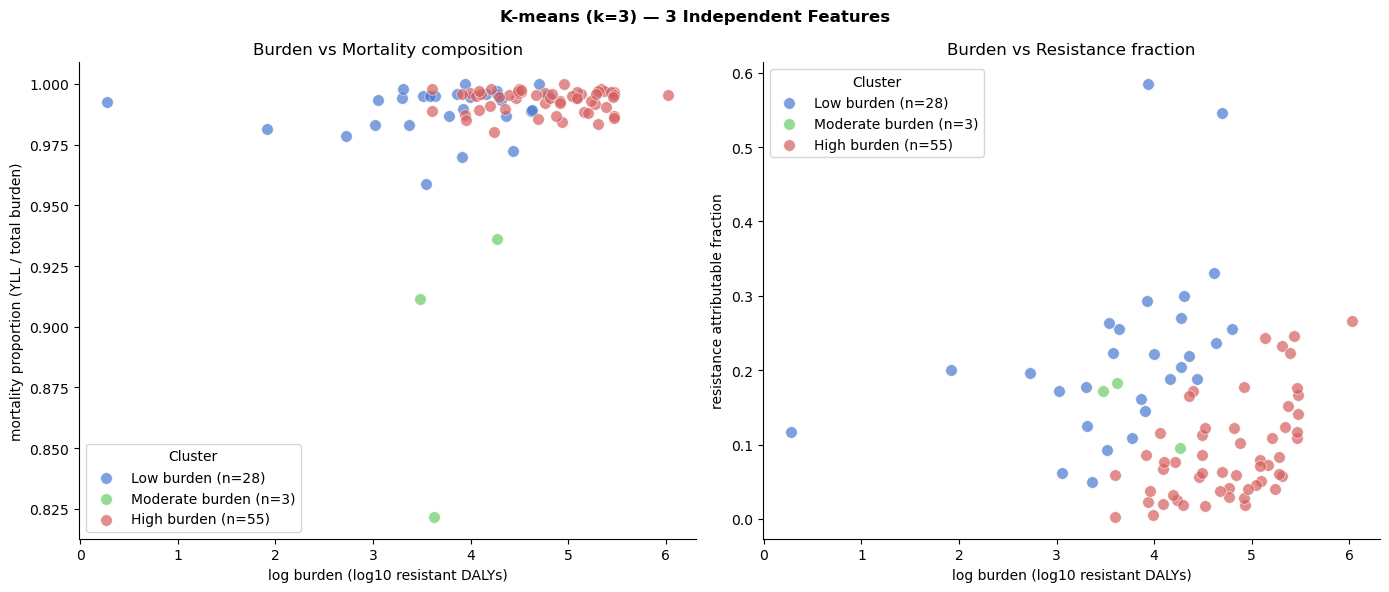

In [66]:
k3 = 3
km3 = KMeans(n_clusters=k3, random_state=42, n_init=10)
fm3['cluster'] = km3.fit_predict(X3)

sort_3 = (fm3.groupby('cluster')['log_burden'].mean().sort_values())

label_map_3 = dict(zip(sort_3.index, ['Low burden', 'Moderate burden', 'High burden']))
fm3['cluster_label'] = fm3['cluster'].map(label_map_3)

cluster_order_3 = ['Low burden', 'Moderate burden', 'High burden']
colors_3 = {
    'Low burden':      '#4878CF',
    'Moderate burden': '#6ACC65',
    'High burden':     '#D65F5F'
}

print("Cluster sizes:")
print(fm3['cluster_label'].value_counts())

print("\nCluster mean profiles:")
print(fm3.groupby('cluster_label')[key_features_3].mean().loc[cluster_order_3].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label in cluster_order_3:
    grp = fm3[fm3['cluster_label'] == label]
    axes[0].scatter(
        grp['log_burden'], grp['mortality_prop'],
        label=f"{label} (n={len(grp)})",
        color=colors_3[label], alpha=0.7, s=70,
        edgecolors='white', linewidths=0.5
    )
    axes[1].scatter(
        grp['log_burden'], grp['resistance_attr_frac'],
        label=f"{label} (n={len(grp)})",
        color=colors_3[label], alpha=0.7, s=70,
        edgecolors='white', linewidths=0.5
    )

axes[0].set_xlabel('log burden (log10 resistant DALYs)')
axes[0].set_ylabel('mortality proportion (YLL / total burden)')
axes[0].set_title('Burden vs Mortality composition')
axes[0].legend(title='Cluster')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].set_xlabel('log burden (log10 resistant DALYs)')
axes[1].set_ylabel('resistance attributable fraction')
axes[1].set_title('Burden vs Resistance fraction')
axes[1].legend(title='Cluster')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle(f'K-means (k={k3}) — 3 Independent Features', fontweight='bold')
plt.tight_layout()
plt.show()

feature_matrix['km_label'] = labels

In [67]:
print("Top combinations by resistant DALYs per cluster:\n")
for label in sorted(fm3['cluster_label'].unique()):
    top = fm3[fm3['cluster_label'] == label] \
        .nlargest(5, 'resistant_dalys')

    print(f"\nCluster {label}")
    print(top[['pathogen', 'antibiotic_class', 'resistant_dalys']])

Top combinations by resistant DALYs per cluster:


Cluster High burden
                   pathogen                 antibiotic_class  resistant_dalys
76    Staphylococcus aureus                      Methicillin     1.062719e+06
28         Escherichia coli  Third-generation cephalosporins     2.974461e+05
3   Acinetobacter baumannii                      Carbapenems     2.950968e+05
27         Escherichia coli                 Fluoroquinolones     2.932156e+05
40    Klebsiella pneumoniae  Third-generation cephalosporins     2.931892e+05

Cluster Low burden
                      pathogen  \
15           Enterobacter spp.   
47  Mycobacterium tuberculosis   
26            Escherichia coli   
20       Enterococcus faecalis   
51           Other enterococci   

                                     antibiotic_class  resistant_dalys  
15                                        Carbapenems     62711.499776  
47  Multi-drug resistance excluding extensive drug...     49695.316272  
26               

In [69]:
fm3.to_csv('amr_feature_matrix.csv', index=False)
print("Saved amr_feature_matrix.csv with cluster labels")
print(f" feature_matrix shape: {fm3.shape}")
print(f"Columns: {list(fm3.columns)}")

Saved amr_feature_matrix.csv with cluster labels
 feature_matrix shape: (86, 12)
Columns: ['pathogen', 'antibiotic_class', 'resistant_dalys', 'resistant_ylls', 'resistant_ylds', 'resistant_deaths', 'total_dalys', 'log_burden', 'mortality_prop', 'resistance_attr_frac', 'cluster', 'cluster_label']
